# Validate `AT_A_1` spike encoding

本 notebook 从 `data/pressure/train/pressure.npy` 读取 `AT_A_1`，以固定随机种子从其**活跃 taxel** 中随机抽取 10 个，并使用 `python_solve_spike_encoding.ipynb` 中的纯 Python 电路系统逐一生成 `final_out`。图中的 `binned spikes` 独立读取自 `data/spike/train/spike.npy`，同时用参考 notebook 的下降沿检测与 240-bin 分箱方法验证两者逐元素一致。

In [1]:
from __future__ import annotations

import csv
from dataclasses import dataclass
from math import exp, log
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

SAMPLE_ID = "AT_A_1"
RANDOM_SEED = 20260816
N_TAXELS = 10
FRAME_COUNT = 240
HEIGHT = 16
WIDTH = 16
DURATION = 2.0


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """向上查找同时包含压力数据和脉冲数据的项目目录。"""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        pressure_path = candidate / "data" / "pressure" / "train" / "pressure.npy"
        spike_path = candidate / "data" / "spike" / "train" / "spike.npy"
        if pressure_path.is_file() and spike_path.is_file():
            return candidate
    raise FileNotFoundError(
        "找不到 data/pressure/train/pressure.npy 或 data/spike/train/spike.npy；"
        "请从 STEMNIST_Classify 项目目录启动 Jupyter。"
    )


def find_manifest_row(manifest_path: Path, sample_id: str) -> dict[str, str]:
    with manifest_path.open("r", encoding="utf-8", newline="") as handle:
        matches = [row for row in csv.DictReader(handle) if row.get("sample_id") == sample_id]
    if len(matches) != 1:
        raise LookupError(
            f"{manifest_path} 中应当恰有一个 {sample_id}，实际找到 {len(matches)} 个。"
        )
    return matches[0]


PROJECT_ROOT = find_project_root()
PRESSURE_DIR = PROJECT_ROOT / "data" / "pressure" / "train"
SPIKE_DIR = PROJECT_ROOT / "data" / "spike" / "train"

pressure_record = find_manifest_row(PRESSURE_DIR / "manifest.csv", SAMPLE_ID)
spike_record = find_manifest_row(SPIKE_DIR / "manifest.csv", SAMPLE_ID)
pressure_index = int(pressure_record["row_index"])
spike_index = int(spike_record["row_index"])

pressure_train = np.load(PRESSURE_DIR / "pressure.npy", mmap_mode="r", allow_pickle=False)
spike_train = np.load(SPIKE_DIR / "spike.npy", mmap_mode="r", allow_pickle=False)
if pressure_train.shape[1:] != (FRAME_COUNT, HEIGHT, WIDTH) or pressure_train.dtype != np.uint8:
    raise ValueError(f"pressure.npy 格式异常：shape={pressure_train.shape}, dtype={pressure_train.dtype}")
if spike_train.shape[1:] != (FRAME_COUNT, HEIGHT, WIDTH) or spike_train.dtype != np.uint8:
    raise ValueError(f"spike.npy 格式异常：shape={spike_train.shape}, dtype={spike_train.dtype}")

pressure = np.asarray(pressure_train[pressure_index]).copy()
binned_spikes = np.asarray(spike_train[spike_index]).copy()
del pressure_train, spike_train

if not np.all((binned_spikes == 0) | (binned_spikes == 1)):
    raise ValueError("data/spike 中的 AT_A_1 不是二值脉冲。")
if pressure_record["sample_id"] != spike_record["sample_id"]:
    raise AssertionError("压力数据与脉冲数据的样本 ID 不一致。")

print(f"项目目录: {PROJECT_ROOT}")
print(f"压力数据: {PRESSURE_DIR / 'pressure.npy'} (row={pressure_index})")
print(f"脉冲数据: {SPIKE_DIR / 'spike.npy'} (row={spike_index})")
print(f"{SAMPLE_ID}: pressure={pressure.shape}/{pressure.dtype}, spikes={binned_spikes.shape}/{binned_spikes.dtype}")


项目目录: C:\Users\Fortyfour\Desktop\STEMNIST_Classify
压力数据: C:\Users\Fortyfour\Desktop\STEMNIST_Classify\data\pressure\train\pressure.npy (row=2251)
脉冲数据: C:\Users\Fortyfour\Desktop\STEMNIST_Classify\data\spike\train\spike.npy (row=2251)
AT_A_1: pressure=(240, 16, 16)/uint8, spikes=(240, 16, 16)/uint8


## 参考电路系统

下面的参数、NbOx 状态切换、突触状态、TIA、电平移位和 U2 振荡器均沿用 `python_solve_spike_encoding.ipynb`。模拟时长为 2 s，步长为 20 μs，共得到 100001 个 `final_out` 电压采样点。

In [3]:
@dataclass(frozen=True)
class SystemModelParameters:
    duration: float = 2.0
    dt: float = 20e-6

    # NbOx oscillators
    vin_u1: float = 2.5
    vh: float = 1.676
    vl: float = 1.127
    rin_nbox: float = 89213.44
    rme_nbox: float = 806.0
    cparal: float = 1e-6
    u2_rload: float = 10e3

    # SYNAPSE_ADV_V2
    synapse_vth: float = 0.679973290013
    synapse_vnorm: float = 2.0
    synapse_pdrive: float = 1.1281797291
    ron1: float = 651321.797132
    roff1: float = 58783.4118027
    ron2: float = 6453.3547737
    roff2: float = 7225.92691131
    ron3: float = 54391.4170977
    roff3: float = 22092.0764053
    g11: float = 0.000663574393119
    g12: float = 0.00122698089109
    g13: float = 4.42225017007e-05
    g23: float = 0.000671314326731
    gv: float = 6.561726644e-06
    synapse_vds: float = 1.0

    # TIA and level shift
    rf1: float = 2.5e3
    cf1: float = 10e-9
    vref: float = 0.75
    rin2: float = 10e3
    rf2: float = 10e3
    negative_rail: float = -5.0
    positive_rail: float = 5.0


PARAMETERS = SystemModelParameters(duration=DURATION, dt=20e-6)
V_ARM = 1.55
V_FIRE = 1.25
REFRACTORY = 0.5e-3
STEP_COUNT = int(round(PARAMETERS.duration / PARAMETERS.dt))
TIME_GRID = np.linspace(0.0, PARAMETERS.duration, STEP_COUNT + 1, dtype=np.float64)
ACTUAL_DT = float(TIME_GRID[1] - TIME_GRID[0])
BIN_DT = PARAMETERS.duration / FRAME_COUNT


In [4]:
def build_pressure_pwl_arrays(pressure_sequence: np.ndarray, edge_time: float = 1e-9):
    """在内存中构造与参考 notebook 相同的 PWL 控制点。"""
    pressure_sequence = np.asarray(pressure_sequence, dtype=np.float64)
    if pressure_sequence.shape != (FRAME_COUNT,):
        raise ValueError(f"压力序列应为 ({FRAME_COUNT},)，实际为 {pressure_sequence.shape}")

    pressure_sequence = np.clip(pressure_sequence, 0.0, 255.0)
    frame_dt = PARAMETERS.duration / FRAME_COUNT
    edge_time = min(edge_time, frame_dt / 1000.0)
    times = [0.0]
    values = [pressure_sequence[0]]

    for frame_index, pressure_value in enumerate(pressure_sequence):
        frame_end = (frame_index + 1) * frame_dt
        times.append(frame_end - edge_time)
        values.append(pressure_value)
        if frame_index + 1 < FRAME_COUNT:
            times.append(frame_end)
            values.append(pressure_sequence[frame_index + 1])

    times.append(PARAMETERS.duration)
    values.append(pressure_sequence[-1])
    return np.asarray(times), np.asarray(values)


def sample_pressure_on_grid(pressure_sequence: np.ndarray) -> np.ndarray:
    times, values = build_pressure_pwl_arrays(pressure_sequence)
    return np.interp(TIME_GRID, times, values)


def advance_nbox_oscillator(
    voltage: float,
    high_resistance: bool,
    input_voltage: float,
    load_resistance: float,
    dt: float,
    par: SystemModelParameters,
) -> tuple[float, bool]:
    """推进一个 RC-NbOx 振荡器，并在单步内解析电阻态切换。"""
    nbox_resistance = par.rin_nbox if high_resistance else par.rme_nbox
    target = input_voltage * nbox_resistance / (load_resistance + nbox_resistance)
    tau = par.cparal / (1.0 / load_resistance + 1.0 / nbox_resistance)
    next_voltage = target + (voltage - target) * exp(-dt / tau)

    crossed_high = high_resistance and next_voltage >= par.vh
    crossed_low = (not high_resistance) and next_voltage <= par.vl
    if not (crossed_high or crossed_low):
        return next_voltage, high_resistance

    threshold = par.vh if high_resistance else par.vl
    ratio = (threshold - target) / (voltage - target)
    crossing_time = -tau * log(ratio)
    remaining_time = max(dt - crossing_time, 0.0)
    high_resistance = not high_resistance

    nbox_resistance = par.rin_nbox if high_resistance else par.rme_nbox
    target = input_voltage * nbox_resistance / (load_resistance + nbox_resistance)
    tau = par.cparal / (1.0 / load_resistance + 1.0 / nbox_resistance)
    next_voltage = target + (threshold - target) * exp(-remaining_time / tau)
    return next_voltage, high_resistance


In [5]:
def simulate_system_python(
    pressure_sequence: np.ndarray,
    parameters: SystemModelParameters = PARAMETERS,
) -> np.ndarray:
    """使用参考 notebook 的纯 Python 电路系统生成一条 final_out 波形。"""
    pressure_grid = sample_pressure_on_grid(pressure_sequence)
    final_out = np.zeros(STEP_COUNT + 1, dtype=np.float64)

    u1_high_resistance = True
    u2_high_resistance = True
    u1_value = 0.0
    vtia_value = 0.0
    state_x1 = state_x2 = state_x3 = 0.0

    x1_on_decay = exp(-ACTUAL_DT / (parameters.ron1 * 1e-6))
    x1_off_decay = exp(-ACTUAL_DT / (parameters.roff1 * 1e-6))
    x2_on_decay = exp(-ACTUAL_DT / (parameters.ron2 * 1e-6))
    x2_off_decay = exp(-ACTUAL_DT / (parameters.roff2 * 1e-6))
    x3_on_decay = exp(-ACTUAL_DT / (parameters.ron3 * 1e-6))
    x3_off_decay = exp(-ACTUAL_DT / (parameters.roff3 * 1e-6))
    tia_decay = exp(-ACTUAL_DT / (parameters.rf1 * parameters.cf1))

    for index in range(1, STEP_COUNT + 1):
        pressure_value = pressure_grid[index - 1]
        if pressure_value > 75.0:
            u1_rload = np.clip(
                900e3 / max(pressure_value - 75.0, 1e-6),
                5e3,
                1e12,
            )
        else:
            u1_rload = 1e12

        u1_value, u1_high_resistance = advance_nbox_oscillator(
            u1_value, u1_high_resistance, parameters.vin_u1, u1_rload, ACTUAL_DT, parameters
        )
        normalized_gate = max(
            (u1_value - parameters.synapse_vth)
            / (parameters.synapse_vnorm - parameters.synapse_vth),
            0.0,
        ) ** parameters.synapse_pdrive

        if u1_value > parameters.synapse_vth:
            state_x1 = normalized_gate + (state_x1 - normalized_gate) * x1_on_decay
            state_x2 = normalized_gate + (state_x2 - normalized_gate) * x2_on_decay
            state_x3 = normalized_gate + (state_x3 - normalized_gate) * x3_on_decay
        else:
            state_x1 *= x1_off_decay
            state_x2 *= x2_off_decay
            state_x3 *= x3_off_decay

        conductance = max(
            parameters.g11 * state_x1 * state_x1
            + parameters.g12 * state_x1 * state_x2
            + parameters.g13 * state_x1 * state_x3
            + parameters.g23 * state_x2 * state_x3
            + parameters.gv * normalized_gate,
            0.0,
        )
        current = parameters.synapse_vds * conductance
        tia_target = -parameters.rf1 * current
        vtia_value = tia_target + (vtia_value - tia_target) * tia_decay
        vtia_value = min(max(vtia_value, parameters.negative_rail), parameters.positive_rail)

        gain = parameters.rf2 / parameters.rin2
        drive = (1.0 + gain) * parameters.vref - gain * vtia_value
        drive = min(max(drive, parameters.negative_rail), parameters.positive_rail)

        final_out[index], u2_high_resistance = advance_nbox_oscillator(
            final_out[index - 1], u2_high_resistance, drive, parameters.u2_rload, ACTUAL_DT, parameters
        )

    return final_out


def detect_u2_spike_times(time: np.ndarray, final_out: np.ndarray) -> np.ndarray:
    """使用参考 notebook 的 armed falling crossing 与不应期检测 spike。"""
    armed = False
    last_spike_time = -np.inf
    spike_times: list[float] = []
    for index in range(1, len(time)):
        if final_out[index] >= V_ARM:
            armed = True
        falling_crossing = final_out[index - 1] > V_FIRE and final_out[index] <= V_FIRE
        outside_refractory = time[index] - last_spike_time >= REFRACTORY
        if armed and falling_crossing and outside_refractory:
            spike_times.append(float(time[index]))
            last_spike_time = time[index]
            armed = False
    return np.asarray(spike_times, dtype=np.float64)


def bin_spike_times(spike_times: np.ndarray) -> np.ndarray:
    counts = np.zeros(FRAME_COUNT, dtype=np.uint16)
    valid = spike_times[(spike_times >= 0.0) & (spike_times < DURATION)]
    indices = np.floor(valid / BIN_DT).astype(np.int64)
    np.add.at(counts, indices, 1)
    return (counts > 0).astype(np.uint8)


## 随机抽取 10 个 taxel 并编码

为了避免随机抽到全程没有脉冲、无法观察对比的 taxel，候选集合限定为 `data/spike` 中至少有一个激活分箱的 taxel；随后使用固定种子无放回随机抽取 10 个。

In [6]:
flat_binned_spikes = binned_spikes.reshape(FRAME_COUNT, -1)
active_taxels = np.flatnonzero(np.any(flat_binned_spikes != 0, axis=0))
if active_taxels.size < N_TAXELS:
    raise ValueError(f"{SAMPLE_ID} 只有 {active_taxels.size} 个活跃 taxel。")

rng = np.random.default_rng(RANDOM_SEED)
selected_taxels = np.sort(rng.choice(active_taxels, size=N_TAXELS, replace=False))
selected_coordinates = [divmod(int(taxel), WIDTH) for taxel in selected_taxels]
selected_taxel_ids = selected_taxels + 1  # 采用 1-based row-major taxel ID

print(f"活跃 taxel 数: {active_taxels.size}")
print("随机选择 (taxel_id, row, column):")
for taxel_id, (row, column) in zip(selected_taxel_ids, selected_coordinates):
    print(f"  ({taxel_id:3d}, {row:2d}, {column:2d})")

final_out_by_taxel = []
reencoded_spikes = []
for number, (taxel_id, (row, column)) in enumerate(
    zip(selected_taxel_ids, selected_coordinates), start=1
):
    final_out = simulate_system_python(pressure[:, row, column])
    encoded = bin_spike_times(detect_u2_spike_times(TIME_GRID, final_out))
    final_out_by_taxel.append(final_out)
    reencoded_spikes.append(encoded)
    print(f"已编码 {number:2d}/{N_TAXELS}: Taxel {taxel_id} (row={row}, col={column})")

final_out_by_taxel = np.stack(final_out_by_taxel)
reencoded_spikes = np.stack(reencoded_spikes)
loaded_spikes = np.stack([binned_spikes[:, row, column] for row, column in selected_coordinates])

mismatch_counts = np.count_nonzero(reencoded_spikes != loaded_spikes, axis=1)
for taxel_id, (row, column), mismatch_count in zip(
    selected_taxel_ids, selected_coordinates, mismatch_counts
):
    active_bins = np.flatnonzero(binned_spikes[:, row, column]).tolist()
    print(
        f"Taxel {taxel_id:3d} (row={row:2d}, col={column:2d}): "
        f"active_bins={active_bins}, mismatches={mismatch_count}"
    )

assert np.array_equal(reencoded_spikes, loaded_spikes), (
    "参考 Python 系统重新编码的结果与 data/spike 中的 binned spikes 不一致。"
)
print("验证通过：10 个 taxel 的重新编码结果均与 data/spike 逐元素一致。")


活跃 taxel 数: 40
随机选择 (taxel_id, row, column):
  ( 56,  3,  7)
  ( 71,  4,  6)
  ( 72,  4,  7)
  (149,  9,  4)
  (151,  9,  6)
  (165, 10,  4)
  (188, 11, 11)
  (189, 11, 12)
  (212, 13,  3)
  (228, 14,  3)
已编码  1/10: Taxel 56 (row=3, col=7)
已编码  2/10: Taxel 71 (row=4, col=6)
已编码  3/10: Taxel 72 (row=4, col=7)
已编码  4/10: Taxel 149 (row=9, col=4)
已编码  5/10: Taxel 151 (row=9, col=6)
已编码  6/10: Taxel 165 (row=10, col=4)
已编码  7/10: Taxel 188 (row=11, col=11)
已编码  8/10: Taxel 189 (row=11, col=12)
已编码  9/10: Taxel 212 (row=13, col=3)
已编码 10/10: Taxel 228 (row=14, col=3)
Taxel  56 (row= 3, col= 7): active_bins=[80, 82, 84, 85, 87, 88, 89, 90, 91, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 117, 118, 120, 122], mismatches=0
Taxel  71 (row= 4, col= 6): active_bins=[77, 78, 79, 81, 83, 85], mismatches=0
Taxel  72 (row= 4, col= 7): active_bins=[78, 79, 80, 81, 82, 84, 86, 88], mismatches=0
Taxel 149 (row= 9, col= 4): active_bins=[64, 6

## `final_out` 与 `binned spikes`

蓝线为参考纯 Python 电路系统生成的 `final_out` 电压；红色阶梯为直接从 `data/spike/train/spike.npy` 读取的 240-bin 二值脉冲。绘图形式沿用 `python_solve_spike_encoding.ipynb` 的双纵轴叠加方式。

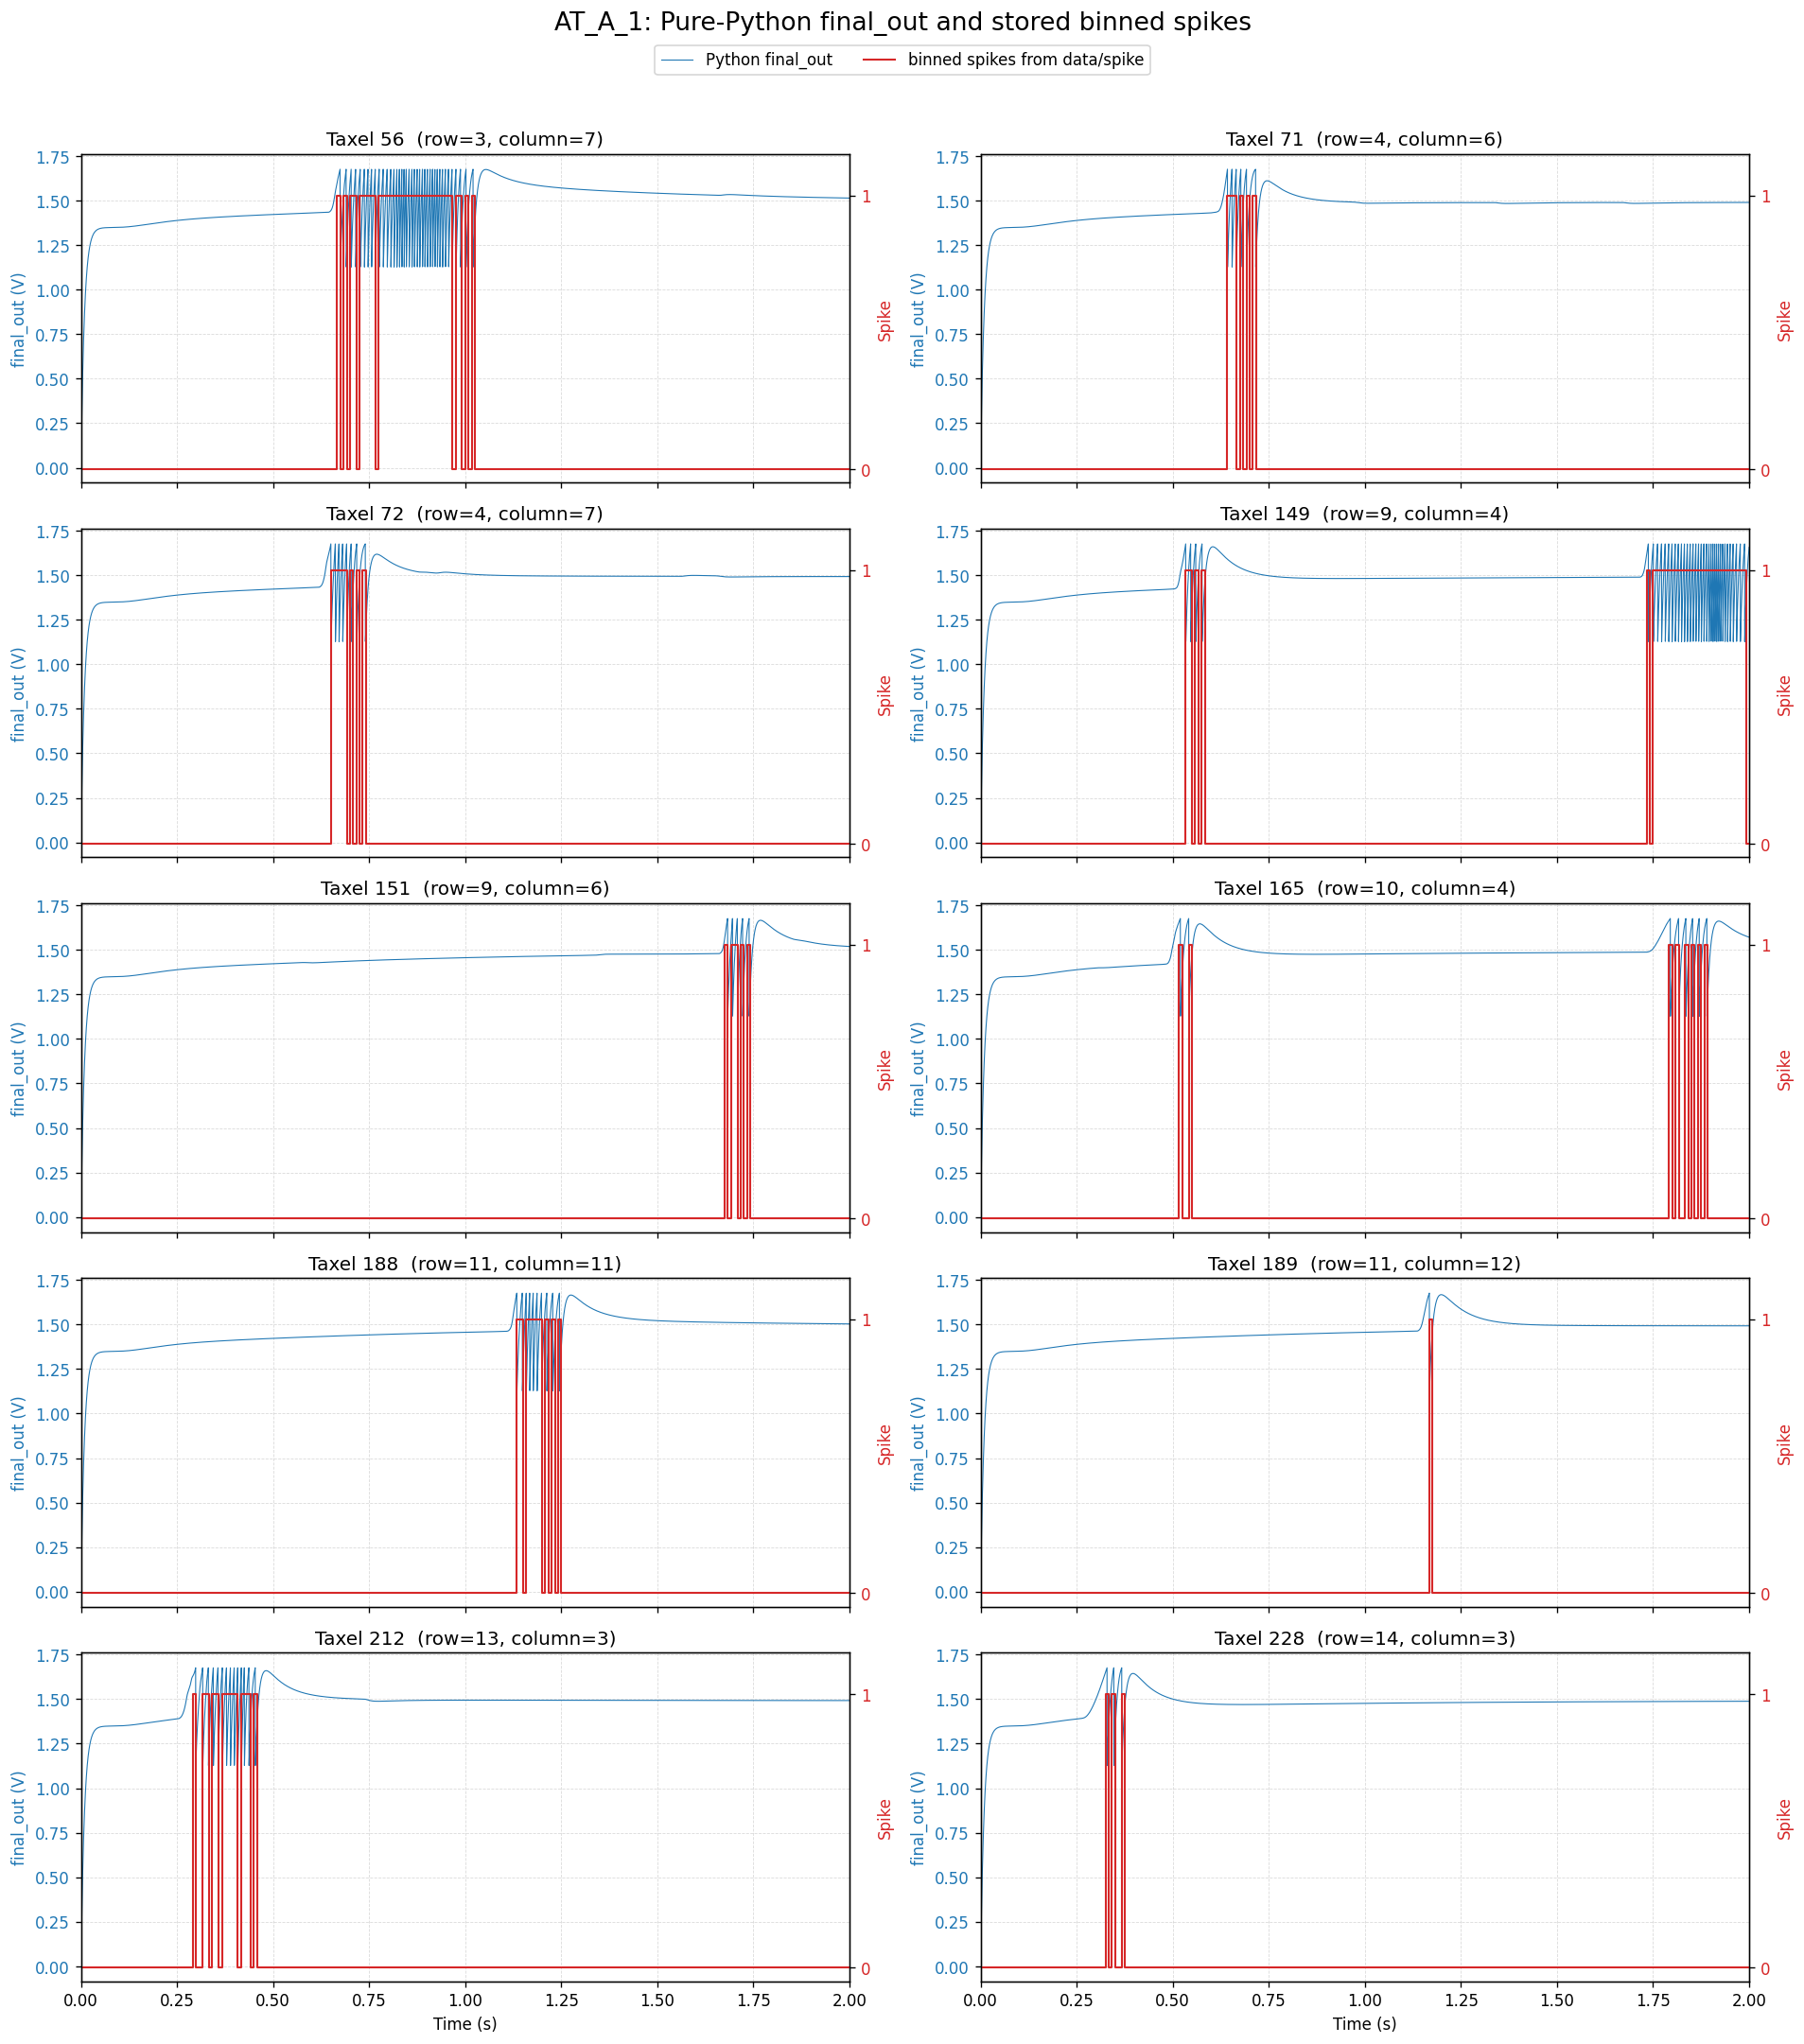

In [7]:
spike_bin_edges = np.linspace(0.0, DURATION, FRAME_COUNT + 1)
fig, voltage_axes = plt.subplots(5, 2, figsize=(16, 18), dpi=120, sharex=True)

voltage_line = spike_line = None
for index, (voltage_ax, taxel_id, coordinate) in enumerate(
    zip(voltage_axes.flat, selected_taxel_ids, selected_coordinates)
):
    row, column = coordinate
    voltage_line, = voltage_ax.plot(
        TIME_GRID, final_out_by_taxel[index], color="#1f77b4", linewidth=0.65, label="Python final_out"
    )
    voltage_ax.set_xlim(0.0, DURATION)
    voltage_ax.set_ylabel("final_out (V)", color="#1f77b4")
    voltage_ax.tick_params(axis="y", labelcolor="#1f77b4")
    voltage_ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
    voltage_ax.set_title(f"Taxel {taxel_id}  (row={row}, column={column})")

    spike_ax = voltage_ax.twinx()
    spikes_for_plot = np.r_[loaded_spikes[index], loaded_spikes[index, -1]]
    spike_line, = spike_ax.step(
        spike_bin_edges, spikes_for_plot, where="post", color="#d62728", linewidth=1.25,
        label="binned spikes from data/spike",
    )
    spike_ax.set_ylim(-0.05, 1.15)
    spike_ax.set_yticks([0, 1])
    spike_ax.set_ylabel("Spike", color="#d62728")
    spike_ax.tick_params(axis="y", labelcolor="#d62728")

for axis in voltage_axes[-1, :]:
    axis.set_xlabel("Time (s)")

fig.legend(
    handles=[voltage_line, spike_line], loc="upper center", ncol=2, bbox_to_anchor=(0.5, 0.985)
)
fig.suptitle(
    f"{SAMPLE_ID}: Pure-Python final_out and stored binned spikes", fontsize=16, y=0.998
)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.968))
plt.show()
